<a href="https://colab.research.google.com/github/musowjanya/Datascience-Project/blob/main/L2T1_TableBooking__and__OnlineDelivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("/content/Dataset .csv")

print(df.columns)
print(df.head())


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chin

In [13]:
df["Has Table booking"] = df["Has Table booking"].map({"Yes": 1, "No": 0})
df["Has Online delivery"] = df["Has Online delivery"].map({"Yes": 1, "No": 0})

In [14]:
total_restaurants = len(df)

table_booking_pct = (df["Has Table booking"].sum() / total_restaurants) * 100
online_delivery_pct = (df["Has Online delivery"].sum() / total_restaurants) * 100

print(f"\nPercentage of restaurants with Table Booking: {table_booking_pct:.2f}%")
print(f"Percentage of restaurants with Online Delivery: {online_delivery_pct:.2f}%")


Percentage of restaurants with Table Booking: 12.12%
Percentage of restaurants with Online Delivery: 25.66%


Average Rating Comparision


Average Ratings based on Table Booking:
 Has Table booking
0    2.559359
1    3.441969
Name: Aggregate rating, dtype: float64


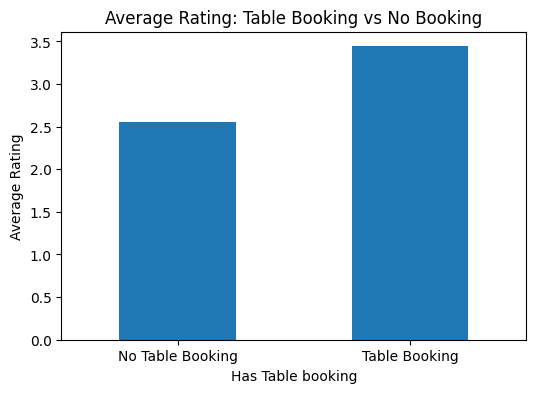

In [15]:
rating_table = df.groupby("Has Table booking")["Aggregate rating"].mean()

print("\nAverage Ratings based on Table Booking:\n", rating_table)

# Visualization
plt.figure(figsize=(6,4))
rating_table.plot(kind='bar')
plt.xticks([0,1], ["No Table Booking", "Table Booking"], rotation=0)
plt.title("Average Rating: Table Booking vs No Booking")
plt.ylabel("Average Rating")
plt.show()

Online Delivery VS price range


Online Delivery Availability by Price Range:
 Price range
1    0.157741
2    0.413106
3    0.291903
4    0.090444
Name: Has Online delivery, dtype: float64


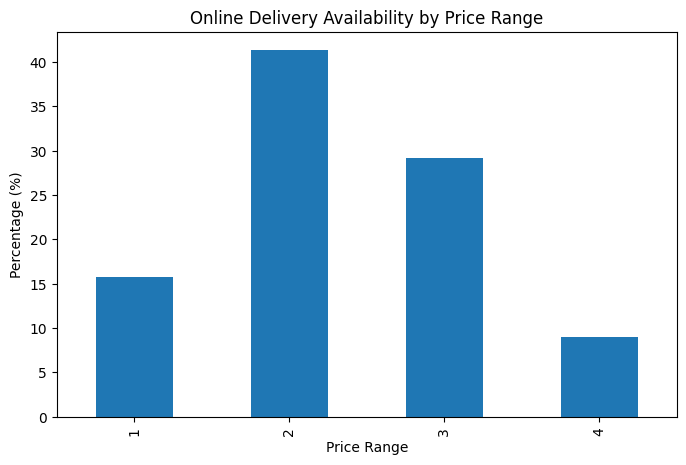

In [16]:
delivery_price = df.groupby("Price range")["Has Online delivery"].mean()

print("\nOnline Delivery Availability by Price Range:\n", delivery_price)

delivery_price_pct = delivery_price * 100

plt.figure(figsize=(8,5))
delivery_price_pct.plot(kind='bar')
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage (%)")
plt.show()

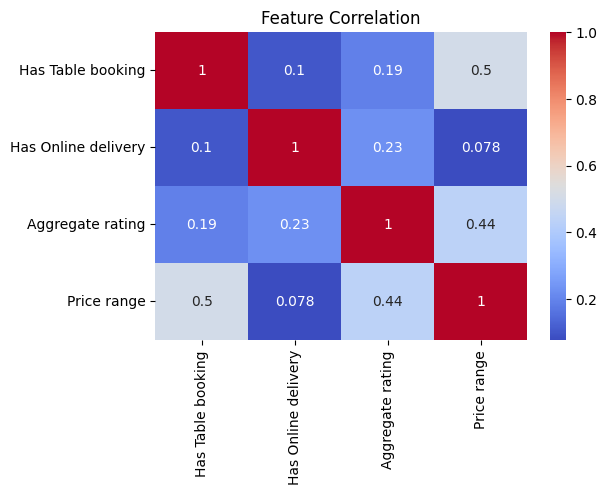

In [17]:
corr = df[["Has Table booking", "Has Online delivery", "Aggregate rating", "Price range"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


Table Booking vs Online Delivery:
 Has Online delivery     0     1
Has Table booking              
0                    6377  2016
1                     723   435


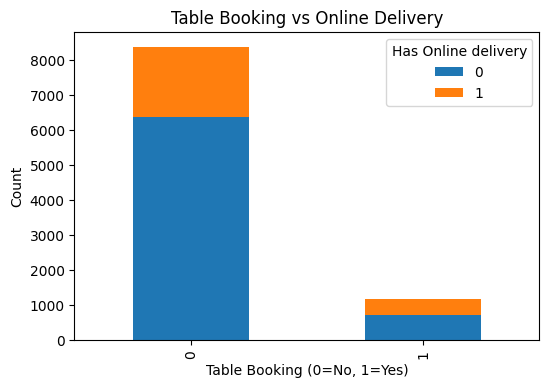

In [18]:
combo = pd.crosstab(df["Has Table booking"], df["Has Online delivery"])

print("\nTable Booking vs Online Delivery:\n", combo)

# Plot
combo.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Table Booking vs Online Delivery")
plt.xlabel("Table Booking (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()